## Modelo de RL para optimización de trayectorias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

### Potenciales para entrenar la particula y función que calcula el gradiente numérico 

In [2]:
# Gaussianas 
def make_gaussians_with_grad(n=3):
    '''
    Funcion que devuelve funciones de potencial con n gaussianas y sus gradientes
    '''
    centers = np.random.uniform(0, 1, size=(n, 2))
    amps = np.random.uniform(0.5, 1.5, size=n)
    sigmas = np.random.uniform(0.05, 0.15, size=n)

    def V(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy
        return -np.sum(amps * np.exp(-r2/(2*sigmas**2)))

    def gradV(x, y):
        dx = x - centers[:,0]
        dy = y - centers[:,1]
        r2 = dx*dx + dy*dy

        exp_term = np.exp(-r2/(2*sigmas**2))
        coeff = amps * exp_term / (sigmas**2)

        gx = np.sum(coeff * dx)
        gy = np.sum(coeff * dy)

        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# Seno/coseno 
def make_sin_with_grad():
    '''
    Funcion equivalente con senos y cosenos
    '''
    def V(x, y):
        return np.sin(3*x)*np.cos(3*y)

    def gradV(x, y):
        gx = 3*np.cos(3*x)*np.cos(3*y)
        gy = -3*np.sin(3*x)*np.sin(3*y)
        grad = np.array([gx, gy], dtype=np.float32)
        return grad / (np.linalg.norm(grad) + 1e-8)

    return V, gradV


# sampler 
def sample_potential():
    '''
    Funcion que elige un potencial aleatorio para pasar al entorno
    '''
    if np.random.rand() < 0.5:
        return make_gaussians_with_grad()
    else:
        return make_sin_with_grad()

## Entorno de la particula
### Toma los pesos del reward como parametro de entrada

In [3]:

class FastGradEnv(gym.Env):
    def __init__(self, max_steps=250, weights = None):
        super().__init__()

        self.max_steps = max_steps
        self.dt = 0.02
        self.speed = 0.25

        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # obs: pos (2) + goal vec (2) + V (1) + grad (2)
        self.observation_space = spaces.Box(
            low=np.array([0,0,-1,-1,-2,-1,-1]),
            high=np.array([1,1,1,1,2,1,1]),
            dtype=np.float32
        )

                # pesos por defecto
        self.weights = weights or {
            "progress": 8.0,
            "align": 1.2,
            "slope": 0.3,
            "potential": 0.05,
            "step": 0.01
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn, self.grad_fn = sample_potential()

        self.pos = self.np_random.uniform(0,1,2).astype(np.float32)
        self.goal = self.np_random.uniform(0,1,2).astype(np.float32)

        self.steps = 0
        return self._obs(), {}

    def _obs(self):
        V = np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2)
        grad = self.grad_fn(self.pos[0], self.pos[1])

        return np.concatenate([
            self.pos,
            self.goal - self.pos,
            [V],
            grad
        ]).astype(np.float32)

    def step(self, action):
        theta = float(action[0] * np.pi)
        direction = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)

        prev_pos = self.pos.copy()
        self.pos += self.speed * direction * self.dt
        self.steps += 1

        dist = np.linalg.norm(self.goal - self.pos)
        prev_dist = np.linalg.norm(self.goal - prev_pos)

        # señales
        r_progress = prev_dist - dist
        r_align = np.dot(direction, (self.goal-self.pos)/(dist+1e-8))

        V = np.clip(self.V_fn(self.pos[0], self.pos[1]), -2, 2)
        grad = self.grad_fn(self.pos[0], self.pos[1])

        r_slope = -np.dot(direction, grad)

        w = self.weights

        reward = (
            w["progress"] * r_progress +
            w["align"] * r_align +
            w["slope"] * r_slope -
            w["potential"] * V -
            w["step"]
        )


        terminated = dist < 0.02
        if terminated:
            reward += 20

        truncated = self.steps >= self.max_steps

        return self._obs(), reward, terminated, truncated, {}

## Cargamos el modelo pre-entrenado
### Se carga al entorno de entrenamiento

In [4]:
env = DummyVecEnv([lambda: FastGradEnv()])
model = SAC.load(path='Fast_v1.zip', env = env)

## Función para evaluar las distintas metricas
### Se compara con la trayectoria en línea recta
### Se incluye un histograma de comparación de las energias

In [5]:
def evaluate(model, env, n_episodes=20, plot_hist=True):
    rewards, lengths, energies, successes, effs = [], [], [], [], []
    linear_energies, ratios = [], []

    for _ in range(n_episodes):
        obs,_ = env.reset()
        start = env.pos.copy()
        goal = env.goal.copy()

        traj = [start.copy()]
        total_r = 0
        energy = 0

        done = False
        term = False

        while not done:
            action,_ = model.predict(obs.reshape(1, -1), deterministic=True)
            action = action[0]

            obs,r,term,trunc,_ = env.step(action)

            total_r += r
            energy += env.V_fn(env.pos[0], env.pos[1])

            traj.append(env.pos.copy())
            done = term or trunc

        traj = np.array(traj)

        # métricas RL
        path_length = np.sum(np.linalg.norm(np.diff(traj, axis=0), axis=1))
        direct_dist = np.linalg.norm(start - goal)

        # trayectoria lineal
        n_points = len(traj)
        xs = np.linspace(start[0], goal[0], n_points)
        ys = np.linspace(start[1], goal[1], n_points)

        energy_lin = 0
        for x, y in zip(xs, ys):
            energy_lin += env.V_fn(x, y)

        ratio = energy / (energy_lin + 1e-8)

        # guardar
        rewards.append(total_r)
        lengths.append(len(traj))
        energies.append(energy)
        linear_energies.append(energy_lin)
        ratios.append(ratio)

        successes.append(float(term))
        effs.append(direct_dist / (path_length + 1e-8))

    # ===== HISTOGRAMA =====
    if plot_hist:
        plt.figure()
        plt.hist(ratios, bins=15)
        plt.axvline(np.mean(ratios), linestyle="--")
        plt.xlabel("Energy ratio (RL / lineal)")
        plt.ylabel("Frecuencia")
        plt.title("Distribución de eficiencia energética")
        plt.show()

    return {
        "reward": float(np.mean(rewards)),
        "success": float(np.mean(successes)),
        "length": float(np.mean(lengths)),
        "energy_rl": float(np.mean(energies)),
        "energy_linear": float(np.mean(linear_energies)),
        "energy_ratio": float(np.mean(ratios)),
        "efficiency": float(np.mean(effs))
    }

## Test con un potencial no visto anteriormente

In [6]:
def V_test(x, y):
    return (
        0.4*np.sin(5*x) * np.cos(4*y)
        + 0.3*np.sin(2*x + y)
        + np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

def grad_test(x, y):
    gx = (
        0.4*5*np.cos(5*x)*np.cos(4*y)
        + 0.3*2*np.cos(2*x + y)
        + ((x-0.2)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*((x-0.7)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    gy = (
        -0.4*4*np.sin(5*x)*np.sin(4*y)
        + 0.3*np.cos(2*x + y)
        + ((y-0.8)/0.01)*np.exp(-((x-0.2)**2 + (y-0.8)**2)/0.01)
        - 1.2*((y-0.3)/0.02)*np.exp(-((x-0.7)**2 + (y-0.3)**2)/0.02)
    )

    grad = np.array([gx, gy], dtype=np.float32)
    return grad / (np.linalg.norm(grad) + 1e-8)

class TestEnv(FastGradEnv):
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.V_fn = V_test
        self.grad_fn = grad_test

        # opcional: evitar casos imposibles
        while True:
            self.pos = self.np_random.uniform(0,1,2)
            self.goal = self.np_random.uniform(0,1,2)
            if np.linalg.norm(self.goal - self.pos) < 0.7:
                break

        return self._obs(), {}


## Fine tunning de los hiper parametros del modelo


=== Bloque 1 ===
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 140      |
|    ep_rew_mean     | 100      |
| time/              |          |
|    episodes        | 1224     |
|    fps             | 69       |
|    time_elapsed    | 2        |
|    total_timesteps | 200140   |
| train/             |          |
|    actor_loss      | -51      |
|    critic_loss     | 0.0469   |
|    ent_coef        | 0.0789   |
|    ent_coef_loss   | -0.502   |
|    learning_rate   | 0.0003   |
|    n_updates       | 200039   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 62.2     |
| time/              |          |
|    episodes        | 1228     |
|    fps             | 96       |
|    time_elapsed    | 10       |
|    total_timesteps | 201001   |
| train/             |          |
|    actor_loss      | -46.5    |
|    critic_loss     | 0.114  

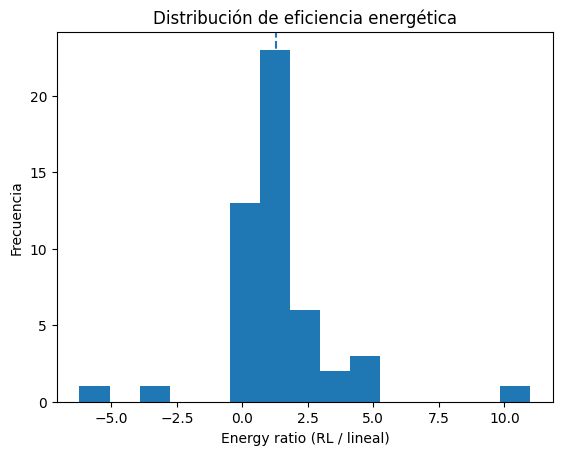

Results: {'reward': 24.75085472670159, 'success': 0.24, 'length': 213.06, 'energy_rl': 36.28814928704712, 'energy_linear': 29.045501758000405, 'energy_ratio': 1.2931598985708839, 'efficiency': 0.45632872228093296}
Score: -0.21994796957126517
✔ Mejor modelo guardado

=== Bloque 2 ===
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 215      |
|    ep_rew_mean     | 39.9     |
| time/              |          |
|    episodes        | 1452     |
|    fps             | 99       |
|    time_elapsed    | 4        |
|    total_timesteps | 250438   |
| train/             |          |
|    actor_loss      | -37.5    |
|    critic_loss     | 0.359    |
|    ent_coef        | 0.0559   |
|    ent_coef_loss   | -0.341   |
|    learning_rate   | 0.0003   |
|    n_updates       | 250337   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 214      |
|    ep_rew_mean     | 42.8     |
| 

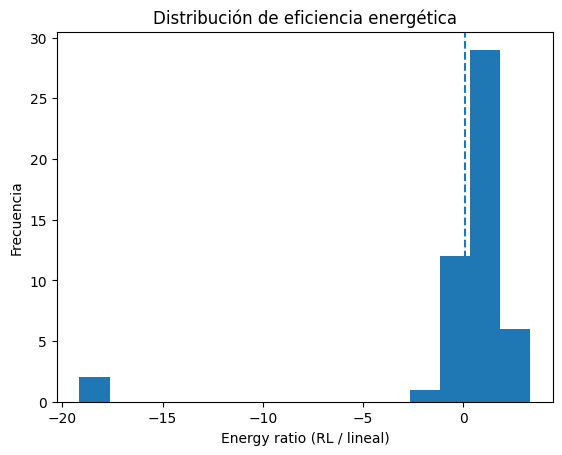

Results: {'reward': 26.944491717735527, 'success': 0.3, 'length': 213.1, 'energy_rl': 29.61233527767515, 'energy_linear': 26.124854572113108, 'energy_ratio': 0.08854164748636423, 'efficiency': 0.4332435754678251}
Score: 0.18343750575409073
✔ Mejor modelo guardado

=== Bloque 3 ===
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 199      |
|    ep_rew_mean     | 65.2     |
| time/              |          |
|    episodes        | 1696     |
|    fps             | 96       |
|    time_elapsed    | 0        |
|    total_timesteps | 300042   |
| train/             |          |
|    actor_loss      | -27.1    |
|    critic_loss     | 0.857    |
|    ent_coef        | 0.0629   |
|    ent_coef_loss   | 0.00038  |
|    learning_rate   | 0.0003   |
|    n_updates       | 299941   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 197      |
|    ep_rew_mean     | 65.3     |
| ti

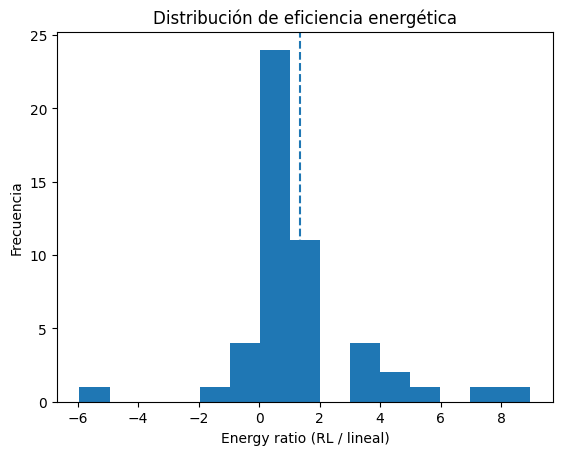

Results: {'reward': 41.24773621328842, 'success': 0.36, 'length': 192.58, 'energy_rl': 12.460986472710076, 'energy_linear': 17.911951832362288, 'energy_ratio': 1.3401517095838396, 'efficiency': 0.5417066918996992}
Score: -0.15004551287515183
Sin mejora (1/2)

=== Bloque 4 ===
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 178      |
|    ep_rew_mean     | 79.2     |
| time/              |          |
|    episodes        | 1972     |
|    fps             | 95       |
|    time_elapsed    | 0        |
|    total_timesteps | 350093   |
| train/             |          |
|    actor_loss      | -24.1    |
|    critic_loss     | 0.641    |
|    ent_coef        | 0.0595   |
|    ent_coef_loss   | -0.00891 |
|    learning_rate   | 0.0003   |
|    n_updates       | 349992   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 176      |
|    ep_rew_mean     | 80.1     |
| time/  

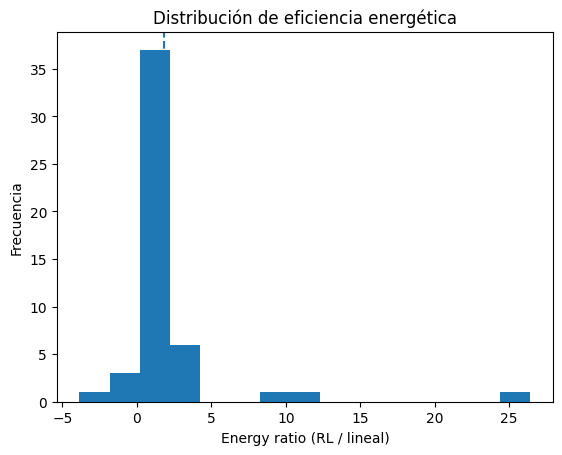

Results: {'reward': 44.96650155893866, 'success': 0.42, 'length': 181.68, 'energy_rl': 20.437160139724053, 'energy_linear': 23.876342122677457, 'energy_ratio': 1.848869054219176, 'efficiency': 0.6126808926621068}
Score: -0.26066071626575277
Sin mejora (2/2)
 Early stopping


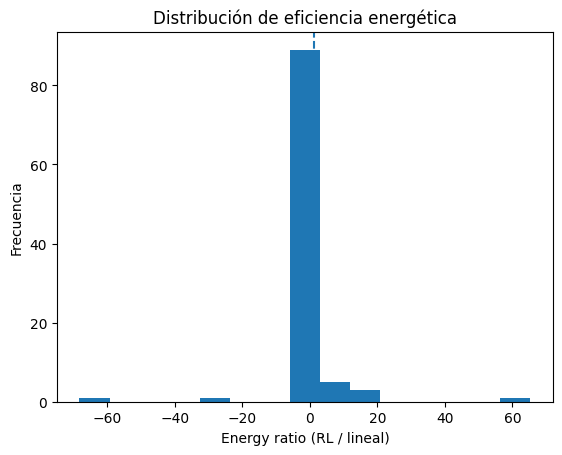


=== RESULTADOS FINALES ===
{'reward': 34.23767612106274, 'success': 0.32, 'length': 206.92, 'energy_rl': 32.489425515082935, 'energy_linear': 27.102998143802733, 'energy_ratio': 1.2113430623870785, 'efficiency': 0.5237269962186664}


In [7]:
from stable_baselines3.common.monitor import Monitor

# ====== pesos ======
weights = {
    "progress": 8.0,
    "align": 0.7,
    "slope": 0.4,
    "potential": 0.025,
    "step": 0.01
}

# ====== DummyVecEnv con lambda ======
env = DummyVecEnv([
    lambda: Monitor(FastGradEnv(weights=weights))
])

# ====== cargar modelo ======
model = SAC.load("Fast_v1.zip", env=env)

# ====== fine-tuning ======
model.learning_rate = 5e-5
model.gamma = 0.995
model.batch_size = 256
model.buffer_size = 200_000
model.learning_starts = 5000
model.ent_coef = "auto_0.02"

# ====== score ======
def eval_score(res):
    return 0.7 * res["success"] - 0.3 * res["energy_ratio"]

# ====== control ======
best_score = -np.inf
best_path = "best_model_ft"
patience = 2
no_improve = 0

total_blocks = 6
steps_per_block = 50_000

# ====== entrenamiento ======
for i in range(total_blocks):
    print(f"\n=== Bloque {i+1} ===")

    model.learn(steps_per_block, reset_num_timesteps=False)

    results = evaluate(model, TestEnv(), n_episodes=50)
    score = eval_score(results)

    print("Results:", results)
    print("Score:", score)

    if score > best_score:
        best_score = score
        no_improve = 0
        model.save(best_path)
        print("✔ Mejor modelo guardado")
    else:
        no_improve += 1
        print(f"Sin mejora ({no_improve}/{patience})")

    if no_improve >= patience:
        print(" Early stopping")
        break

# ====== cargar mejor ======
model = SAC.load(best_path, env=env)

# ====== evaluación final ======
final_results = evaluate(model, TestEnv(), n_episodes=100)

print("\n=== RESULTADOS FINALES ===")
print(final_results)

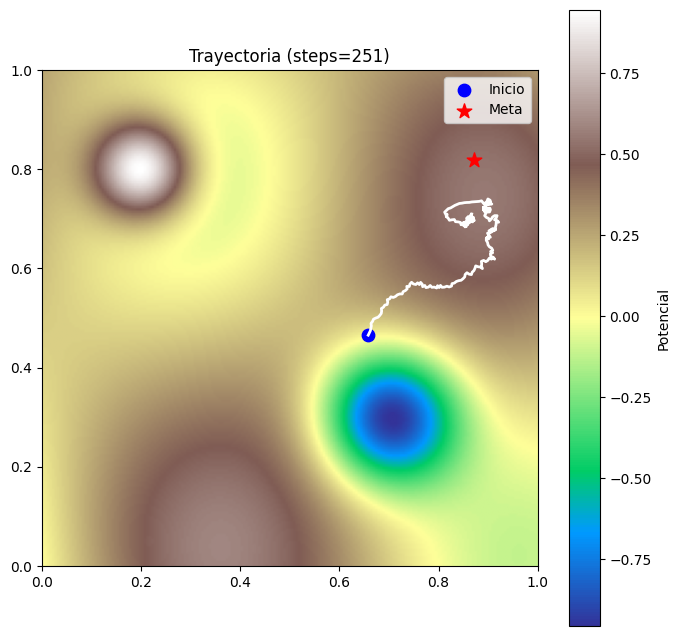

In [19]:
def test_and_plot(model, env, start, goal):
    obs,_ = env.reset()

    # fijar condiciones
    env.pos = np.array(start, dtype=np.float32)
    env.goal = np.array(goal, dtype=np.float32)

    # reconstruir observación correcta
    obs = env._obs()

    traj = [env.pos.copy()]
    done = False

    while not done:
        action,_ = model.predict(obs.reshape(1, -1), deterministic=False)
        action = action[0]

        obs,_,term,trunc,_ = env.step(action)
        traj.append(env.pos.copy())

        done = term or trunc

    traj = np.array(traj)

    # ===== mapa =====
    res = 200
    xs = np.linspace(0,1,res)
    ys = np.linspace(0,1,res)
    X, Y = np.meshgrid(xs, ys)

    Z = np.zeros_like(X)
    for i in range(res):
        for j in range(res):
            Z[i,j] = env.V_fn(X[i,j], Y[i,j])

    # ===== plot =====
    plt.figure(figsize=(8,8))
    plt.imshow(Z, origin="lower", extent=[0,1,0,1], cmap="terrain")
    plt.colorbar(label="Potencial")

    plt.plot(traj[:,0], traj[:,1], "w-", linewidth=2)

    plt.scatter(start[0], start[1], c="blue", s=80, label="Inicio")
    plt.scatter(goal[0], goal[1], c="red", s=120, marker="*", label="Meta")

    plt.legend()
    plt.title(f"Trayectoria (steps={len(traj)})")
    plt.show()

    return traj

env = TestEnv()
traj = test_and_plot(
    model,
    TestEnv(),
    start=np.random.random(2),
    goal=np.random.random(2)
)